# FX OHLCV Query — Exchange Rate Data with Volume

The `macro_data` package's canonical store keeps one `value` per date (a closing price/level) — enough for FX rates, indices, and macro indicators, but not for OHLCV bars. This notebook queries **Open/High/Low/Close/Volume** directly via `yfinance`, bypassing the single-value store, and shows it alongside the standard package for context.

Sections:
1. Spot FX OHLCV — and why `Volume` is always zero
2. FX futures OHLCV — where `Volume` is real
3. Candlestick + volume chart
4. Multi-ticker OHLCV snapshot
5. Saving OHLCV bars to CSV (separate from the canonical store)

In [1]:
import pandas as pd
import yfinance as yf
import mplfinance as mpf
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 20)
%matplotlib inline


def fetch_ohlcv(ticker: str, period: str = "3mo", interval: str = "1d") -> pd.DataFrame:
    """Query full OHLCV bars for a ticker directly from Yahoo Finance."""
    df = yf.Ticker(ticker).history(period=period, interval=interval)
    return df[["Open", "High", "Low", "Close", "Volume"]]

## 1. Spot FX OHLCV

`THB=X` and `EURUSD=X` are spot FX pairs — traded over-the-counter across a decentralized network of banks and dealers, with no single exchange tape. Yahoo still returns Open/High/Low/Close for these (derived from quote data), but `Volume` is always `0` because there's no consolidated trade volume to report.

In [2]:
usd_thb_ohlcv = fetch_ohlcv("THB=X")
eur_usd_ohlcv = fetch_ohlcv("EURUSD=X")

usd_thb_ohlcv.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2026-07-06 00:00:00+01:00,33.240002,33.349998,33.139999,33.240002,0
2026-07-07 00:00:00+01:00,33.290001,33.353001,33.220001,33.266998,0
2026-07-08 00:00:00+01:00,33.356998,33.529999,33.340000,33.360001,0
2026-07-09 00:00:00+01:00,33.414001,33.523998,33.354000,33.470001,0
2026-07-10 00:00:00+01:00,33.330002,33.389999,33.209999,33.299999,0


In [3]:
print("USD/THB total volume over period:", usd_thb_ohlcv["Volume"].sum())
print("EUR/USD total volume over period:", eur_usd_ohlcv["Volume"].sum())

USD/THB total volume over period: 0
EUR/USD total volume over period: 0


## 2. FX futures OHLCV

Currency **futures** (traded on CME, ticker suffix `=F`) do clear through a central exchange, so their volume is real and meaningful. `6E=F` (Euro FX), `6J=F` (Japanese Yen), and `6B=F` (British Pound) are the CME futures contracts for those currency pairs against USD.

In [4]:
futures_tickers = {"6E=F": "Euro FX futures", "6J=F": "Yen futures", "6B=F": "British Pound futures"}
futures_ohlcv = {ticker: fetch_ohlcv(ticker) for ticker in futures_tickers}

futures_ohlcv["6E=F"].tail()

,Open,High,Low,Close,Volume
Date,,,,,
2026-07-06 00:00:00-04:00,1.14355,1.14480,1.14115,1.14465,2161
2026-07-07 00:00:00-04:00,1.14450,1.14490,1.14115,1.14215,882
2026-07-08 00:00:00-04:00,1.14085,1.14325,1.13945,1.14275,619
2026-07-09 00:00:00-04:00,1.14190,1.14470,1.14190,1.14340,619
2026-07-10 00:00:00-04:00,1.14600,1.14910,1.14590,1.14685,24878


In [5]:
for ticker, name in futures_tickers.items():
    total_volume = futures_ohlcv[ticker]["Volume"].sum()
    print(f"{ticker:8s} {name:22s} total volume over period: {total_volume:,}")

6E=F     Euro FX futures        total volume over period: 4,370,675
6J=F     Yen futures            total volume over period: 2,951,416
6B=F     British Pound futures  total volume over period: 1,768,272


## 3. Candlestick + volume chart

`mplfinance` renders OHLCV bars as a standard candlestick chart with a volume panel underneath — the typical way to visualize this kind of data.

findfont: Failed to find font weight semibold, now using 700.


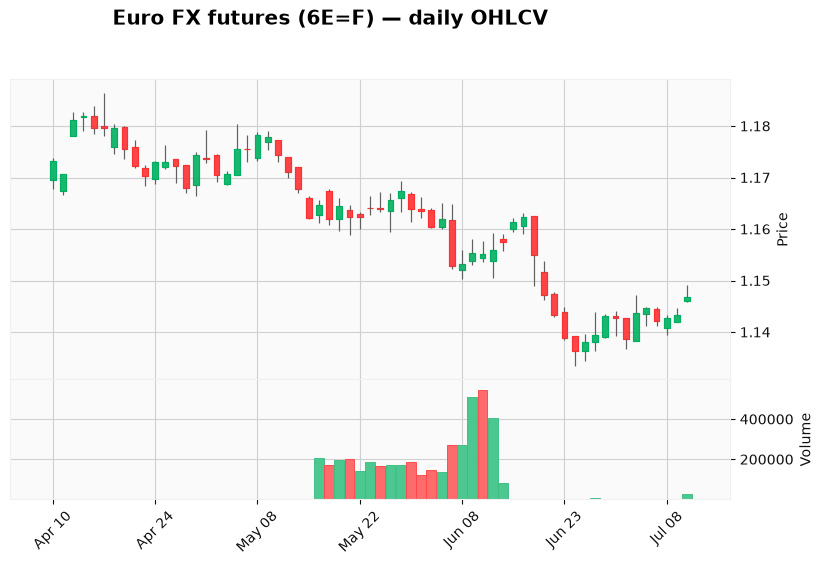

In [6]:
mpf.plot(
    futures_ohlcv["6E=F"],
    type="candle",
    volume=True,
    style="yahoo",
    title="Euro FX futures (6E=F) — daily OHLCV",
    figsize=(10, 6),
)

## 4. Multi-ticker OHLCV snapshot

The latest bar for every ticker queried so far, spot and futures side by side.

In [7]:
all_ohlcv = {
    "THB=X (spot)": usd_thb_ohlcv,
    "EURUSD=X (spot)": eur_usd_ohlcv,
    **{f"{t} ({name})": df for (t, name), df in zip(futures_tickers.items(), futures_ohlcv.values())},
}

snapshot = pd.DataFrame(
    {label: df.iloc[-1] for label, df in all_ohlcv.items()}
).T
snapshot

,Open,High,Low,Close,Volume
THB=X (spot),33.330002,33.389999,33.209999,33.299999,0.0
EURUSD=X (spot),1.143511,1.146395,1.143118,1.144296,0.0
6E=F (Euro FX futures),1.146000,1.149100,1.145900,1.146850,24878.0
6J=F (Yen futures),0.006184,0.006231,0.006184,0.006218,78932.0
6B=F (British Pound futures),1.340700,1.345100,1.340700,1.342400,9816.0


## 5. Saving OHLCV bars to CSV

These bars have five value columns per date, so they don't fit the package's single-`value` canonical schema (`macro_data.schema`/`store`) — that store is deliberately kept simple for series like FX levels and macro indicators. OHLCV bars are saved here to their own folder, `data/yahoo_ohlcv/<ticker>.csv`, independent of `data/yahoo/`.

In [8]:
from pathlib import Path

ohlcv_dir = Path("..") / "data" / "yahoo_ohlcv"
ohlcv_dir.mkdir(parents=True, exist_ok=True)

all_tickers = {"THB=X": usd_thb_ohlcv, "EURUSD=X": eur_usd_ohlcv, **futures_ohlcv}
for ticker, df in all_tickers.items():
    safe_name = ticker.replace("=", "_")
    df.to_csv(ohlcv_dir / f"{safe_name}.csv", index_label="Date")

sorted(p.name for p in ohlcv_dir.glob("*.csv"))

['6B_F.csv', '6E_F.csv', '6J_F.csv', 'EURUSD_X.csv', 'THB_X.csv']